### Aircraft Engine Remaining Useful Life (RUL) Prediction
**NASA C-MAPSS Turbofan Engine Dataset**

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import xgboost as xgb
warnings.filterwarnings('ignore')

In [3]:
# contsnats -> in constants file
PARENT_DIR = "data"
TRAINING_DATA = "train_FD001.txt"
TEST_DATA = "test_FD001.txt"
RUL_DATA = "RUL_FD001.txt"
TRAIN_DATA_PATH = os.path.join(PARENT_DIR, TRAINING_DATA)
TEST_DATA_PATH = os.path.join(PARENT_DIR, TEST_DATA)
RUL_DATA_PATH = os.path.join(PARENT_DIR, RUL_DATA)


**What's happening here:**

The dataset is a plain text file with space-separated values and no header row. So we define column names manually.

Structure of each row:
- `unit` — which engine (1 to 100)
- `cycle` — which operational cycle
- `op_setting_1, 2, 3` — operating conditions (altitude, throttle, speed)
- `sensor_1` to `sensor_21` — 21 sensor measurements per cycle

Three files:
- `train_FD001.txt` — full run-to-failure data for 100 engines
- `test_FD001.txt` — partial sequences, cut off before failure
- `RUL_FD001.txt` — true RUL values for each engine in test set at the cutoff point


In [4]:
# load data -> functions in custom lib

# 26 columns: unit, cycle, 3 operational settings, 21 sensor readings
columns = ['unit', 'cycle'] + [f'op_setting_{i}' for i in range(1, 3+1)] + \
    [f'sensor_{i}' for i in range(1, 21+1)]

def load_data(filepath:str, sep:str="\s+", header=None, col_names:list=columns) -> pd.DataFrame:
    df = pd.read_csv(filepath, sep=sep, header=header, names=col_names, engine='python')
    df.dropna(axis=1, inplace=True)
    return df

train_data = load_data(filepath=TRAIN_DATA_PATH)
test_data = load_data(filepath=TEST_DATA_PATH)
rul_data = load_data(filepath=RUL_DATA_PATH, col_names=['RUL'])

In [5]:
print(f"Training Data Shape: {train_data.shape}")
print(f"Testing Data Shape: {test_data.shape}")
print(f"Engines in train: {train_data['unit'].nunique()}")
print(f"Engines in test: {test_data['unit'].nunique()}")

Training Data Shape: (20631, 26)
Testing Data Shape: (13096, 26)
Engines in train: 100
Engines in test: 100


### EDA

In [6]:
train_data.head()

,unit,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [7]:
train_data.groupby('unit')['cycle'].max().describe()

count    100.000000
mean     206.310000
std       46.342749
min      128.000000
25%      177.000000
50%      199.000000
75%      229.250000
max      362.000000
Name: cycle, dtype: float64

count    100.000000
mean     206.310000
std       46.342749
min      128.000000
25%      177.000000
50%      199.000000
75%      229.250000
max      362.000000
Name: cycle, dtype: float64


Text(0.5, 1.0, 'Distribution of Engine Lifespan')

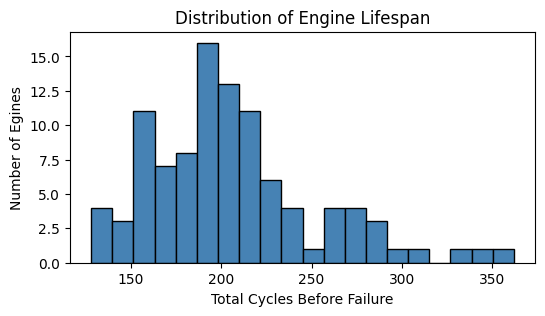

In [8]:
# how many cycles does each engine lasts
engine_life = train_data.groupby('unit')['cycle'].max()
print(engine_life.describe())
plt.figure(figsize=(6,3))
# sns.histplot(engine_life, bins=10, color='steelblue', edgecolor='black')
plt.hist(engine_life, bins=20, color='steelblue', edgecolor='black')
plt.xlabel("Total Cycles Before Failure")
plt.ylabel("Number of Egines")
plt.title("Distribution of Engine Lifespan")

We calculate standard deviation for each of the 21 sensors across the entire training dataset.

If a sensor has std close to zero - it means it barely changes across all engines and all cycles.
A flat signal carries no information about degradation. Including it would just add noise to the model.


In [9]:
sensor_cols = [col for col in train_data.columns.to_list() if col.startswith("sensor_")]
sensor_std = train_data[sensor_cols].std()

print(f"Sensors with near zero variance:\n{sensor_std[sensor_std < 0.01]}")

drop_sensors = sensor_std[sensor_std < 0.01].index.to_list()
print(f"dropping sensors: {drop_sensors}")

train_data.drop(labels=drop_sensors, axis=1, inplace=True)

Sensors with near zero variance:
sensor_1     0.000000e+00
sensor_5     5.329200e-15
sensor_6     1.388985e-03
sensor_10    0.000000e+00
sensor_16    3.469531e-18
sensor_18    0.000000e+00
sensor_19    0.000000e+00
dtype: float64
dropping sensors: ['sensor_1', 'sensor_5', 'sensor_6', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']


###  Sensor Degradation Visualization

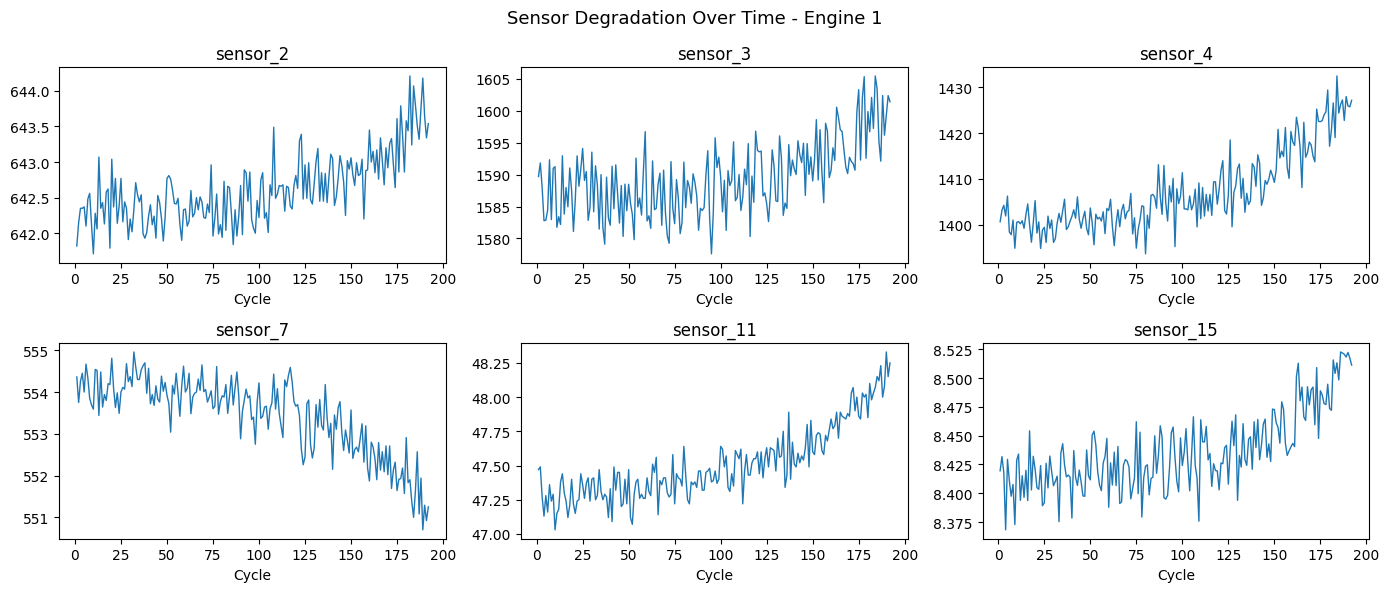

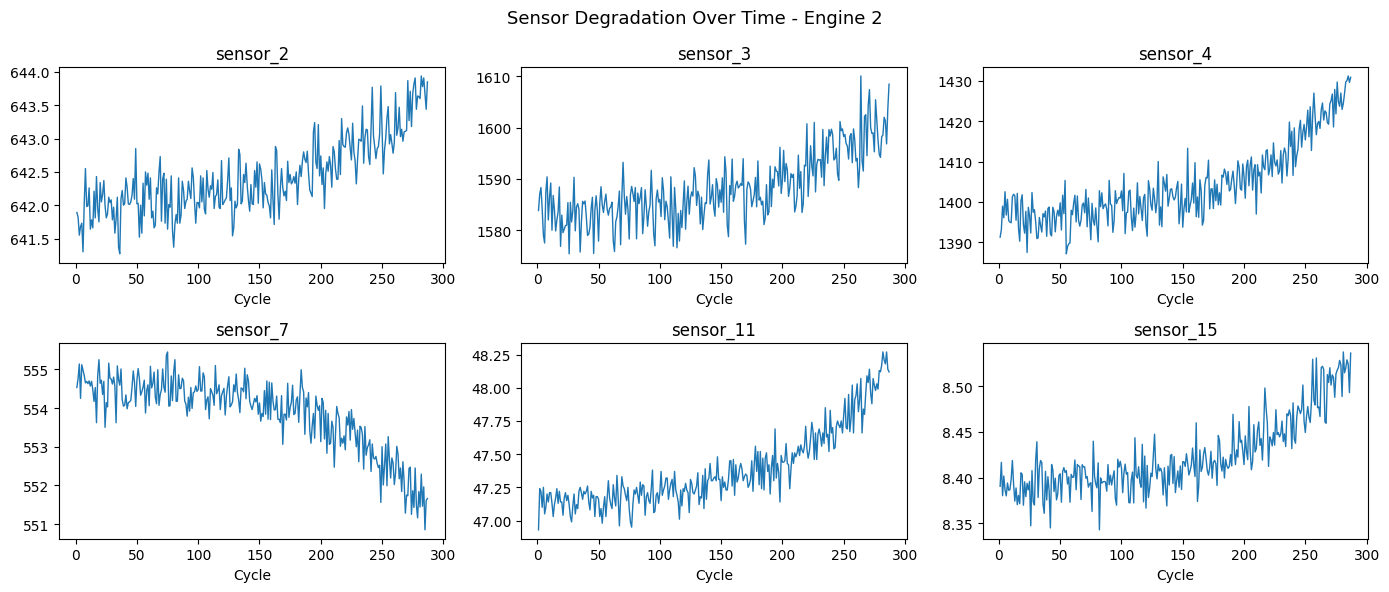

In [10]:
# Visualize degradation in a few key sensors for one engine
# Good sensors to visualize: sensor_2, sensor_3, sensor_4, sensor_7, sensor_11

for i in range(train_data['unit'].min(), 3):
    sample_engine = train_data[train_data['unit'] == i]

    plot_sensors = ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_11', 'sensor_15']

    fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(14, 6))

    for ax, sensor in zip(axes.flatten(), plot_sensors):
        ax.plot(sample_engine['cycle'], sample_engine[sensor], linewidth=1)
        ax.set_title(sensor)
        ax.set_xlabel('Cycle')

    plt.suptitle(f"Sensor Degradation Over Time - Engine {i}", fontsize=13)
    plt.tight_layout()


**Why sensor 7 declines:** Sensor 7 in C-MAPSS measures static pressure ratio at the fan — as the engine degrades, fan efficiency drops, so pressure ratio decreases. Declining pressure = engine working harder to produce the same output = wear accumulating.

**Why others rise:** Sensors like 2, 3, 4 measure temperatures at different stages of the engine — as components wear, friction increases, heat increases. Rising temperature over time = degradation signature.

### RUL Label Generation

In [11]:
max_cycles = train_data.groupby('unit')['cycle'].max().reset_index()
max_cycles.columns = ['unit', 'max_cycle']

train_data = train_data.merge(max_cycles, on='unit')
train_data['RUL'] = train_data['max_cycle'] - train_data['cycle']

# applying piecewise linear cap at 125 cycles
RUL_CAP = 125
train_data['RUL_CAPPED'] = train_data['RUL'].clip(upper=RUL_CAP)

print('RUL distribution after capping:')
print(train_data['RUL'].describe())

RUL distribution after capping:
count    20631.000000
mean       107.807862
std         68.880990
min          0.000000
25%         51.000000
50%        103.000000
75%        155.000000
max        361.000000
Name: RUL, dtype: float64


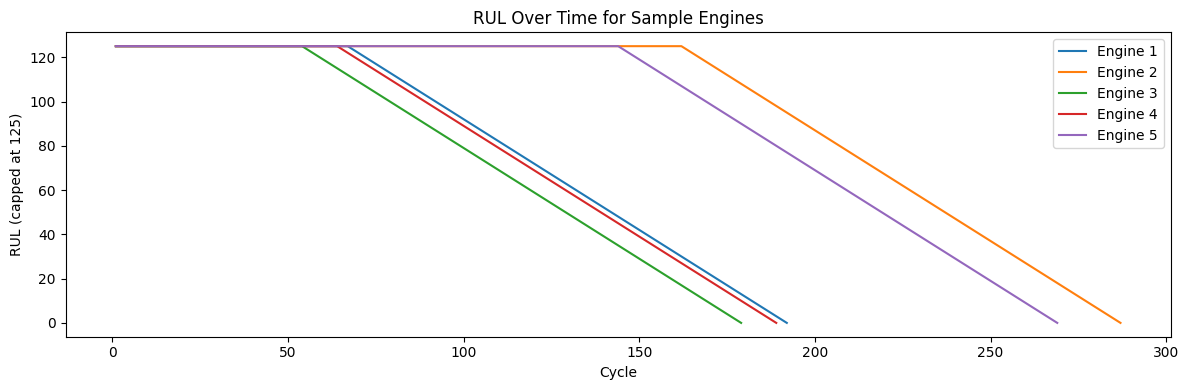

In [12]:
plt.figure(figsize=(12, 4))
for engine_id in [1, 2, 3, 4, 5]:
    engine_data = train_data[train_data['unit'] == engine_id]
    plt.plot(engine_data['cycle'], engine_data['RUL_CAPPED'], label=f'Engine {engine_id}')
plt.xlabel('Cycle')
plt.ylabel('RUL (capped at 125)')
plt.title('RUL Over Time for Sample Engines')
plt.legend()
plt.tight_layout()
plt.show()

### Feature Engineering

**We have 14 useful sensors after dropping constants. For each sensor we create two new features:**

- `Rolling mean (window=10):` Average sensor reading over last 10 cycles. This smooths out noise — a single cycle reading can spike randomly, but the average over 10 cycles reflects the true trend.
- `Rolling std (window=10):` Standard deviation of sensor over last 10 cycles. This captures variability- as an engine degrades, sensor readings often become more erratic. Rising std can signal that degradation is accelerating.
- `groupby('unit')`: critical. Rolling is computed per engine separately. You don't want cycle 200 of Engine 1 influencing cycle 1 of Engine 2.
- `min_periods=1` - for early cycles where we don't have 10 cycles yet, compute rolling stats with whatever cycles are available. Without this, first 9 cycles of every engine would be NaN.

In [13]:
def add_rolling_features(df:pd.DataFrame, sensors, window=10) -> pd.DataFrame:
    df = df.copy()
    for sensor in sensors:
        df[f'{sensor}_roll_mean'] = df.groupby('unit')[sensor].transform(
            lambda x: x.rolling(window, min_periods=1).mean())
        df[f'{sensor}_roll_std'] = df.groupby('unit')[sensor].transform(
            lambda x: x.rolling(window, min_periods=1).std().fillna(0)
        )
    return df

useful_sensors = [col for col in train_data.columns if col.startswith("sensor_")]
train_data = add_rolling_features(df=train_data, sensors=useful_sensors)
test_data = add_rolling_features(df=test_data, sensors=useful_sensors)

### Prepare Train and Test Sets

In [14]:
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler

feature_cols = [col for col in train_data.columns if col.startswith(
    ('sensor_', 'cycle', 'op_setting_'))]

X_train = train_data[feature_cols]
y_train = train_data['RUL_CAPPED']
groups = train_data['unit']

# test set: take last cycle per engine, add tru RUL
test_last = test_data.groupby('unit').last().reset_index()
test_last['RUL'] = rul_data['RUL'].values

X_test = test_last[feature_cols]
y_test = test_last['RUL']

In [15]:
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### XGBoost Model and Cross Validation

**XGBoost parameters:**
- `n_estimators=300` - number of trees to build sequentially. Each tree corrects errors of the previous one. 300 is a reasonable starting point — not too few to underfit, not too many to overfit.
- `max_depth=6` - how deep each tree can grow. Deeper trees capture more complex patterns but risk overfitting. 6 is standard for tabular data.
- `learning_rate=0.05` - how much each tree contributes to the final prediction. Lower rate = more trees needed but better generalization. 0.05 with 300 trees is a common balanced combination.
- `subsample=0.8` - each tree only sees 80% of training rows randomly selected. Prevents any single tree from memorizing the data.
- `colsample_bytree=0.8` - each tree only sees 80% of features randomly selected. Similar to random forests- adds diversity across trees.
- `random_state=42` - reproducibility. Same results every run.
- `n_jobs=-1` - use all CPU cores for parallel training.


In [16]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

# XGBoost Model
model = XGBRegressor(
    n_estimator = 300,
    max_depth = 6,
    learning_rate = 0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

gkf = GroupKFold(n_splits=5)
cv_rmse = []

for fold, (train_idx, val_idx) in enumerate(gkf.split(X=X_train, y=y_train, groups=groups)):
    X_tr, X_val = X_train_scaled[train_idx], X_train_scaled[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
    preds = model.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, preds))
    cv_rmse.append(rmse)
    print(f'Fold: {fold}, RMSE: {rmse:.2f}')

print(f'\nMean CV RMSE: {np.mean(cv_rmse):.2f} (+/- {np.std(cv_rmse):.2f})')

Fold: 0, RMSE: 16.92
Fold: 1, RMSE: 17.36
Fold: 2, RMSE: 14.27
Fold: 3, RMSE: 17.81
Fold: 4, RMSE: 16.19

Mean CV RMSE: 16.51 (+/- 1.24)


XGBoost baseline with rolling features achieved a mean CV RMSE of 16.5 cycles with a standard deviation of 1.24 across 5 folds - consistent performance across unseen engines. Given average engine life of ~206 cycles that's roughly 8% (16.5/206) prediction error at baseline before any tuning.

###  Final Test Set Evaluation

In [17]:
# training final model on full training data and evaluation with full test data
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

# cliping predictions to valid range
y_pred = np.clip(y_pred, 0, RUL_CAP)

test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
test_mae = mean_absolute_error(y_test, y_pred)

print('=== Test Set Results ===')
print(f'RMSE: {test_rmse:.2f} cycles')
print(f'MAE:  {test_mae:.2f} cycles')
print(f'\nInterpretation: On average predictions are off by ~{test_mae:.0f} cycles')

=== Test Set Results ===
RMSE: 19.01 cycles
MAE:  13.94 cycles

Interpretation: On average predictions are off by ~14 cycles


### Predicted vs actual scatter plot

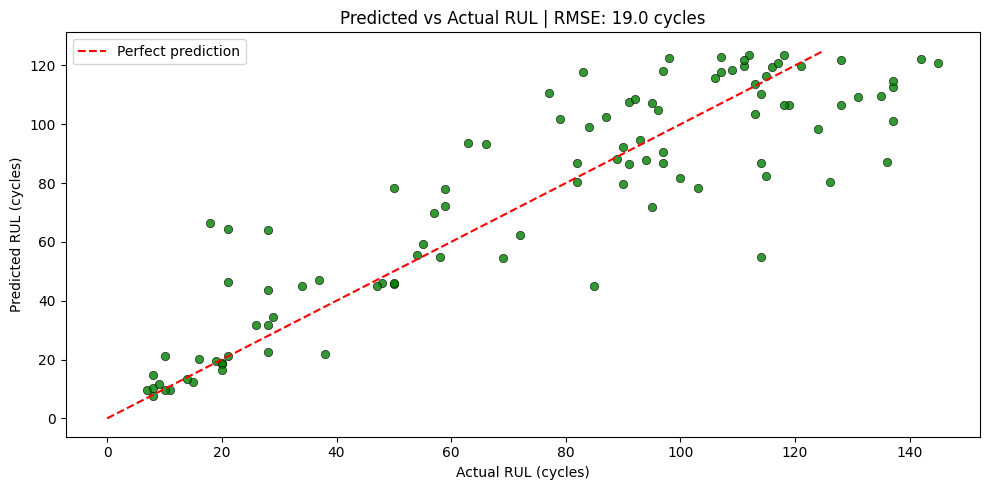

In [18]:
# Predicted vs Actual RUL
plt.figure(figsize=(10, 5))
plt.scatter(y_test, y_pred, alpha=0.8, color='green', 
            edgecolors='black', linewidth=0.5)
plt.plot([0, RUL_CAP], [0, RUL_CAP], 'r--', label='Perfect prediction')
plt.xlabel('Actual RUL (cycles)')
plt.ylabel('Predicted RUL (cycles)')
plt.title(f'Predicted vs Actual RUL | RMSE: {test_rmse:.1f} cycles')
plt.legend()
plt.tight_layout()
plt.show()

### Error distribution plot

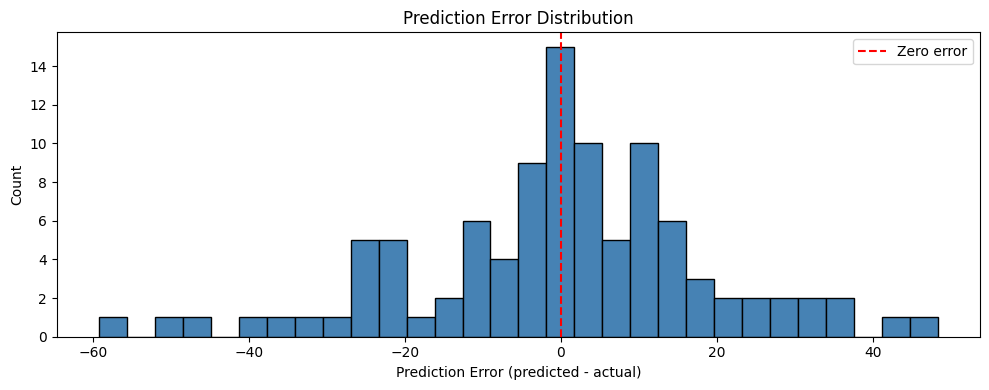

Mean error: -0.03 cycles (positive = overestimating RUL)
Std error:  19.01 cycles


In [19]:
# Prediction error distribution
errors = y_pred - y_test.values

plt.figure(figsize=(10, 4))
plt.hist(errors, bins=30, color='steelblue', edgecolor='black')
plt.axvline(0, color='red', linestyle='--', label='Zero error')
plt.xlabel('Prediction Error (predicted - actual)')
plt.ylabel('Count')
plt.title('Prediction Error Distribution')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Mean error: {errors.mean():.2f} cycles (positive = overestimating RUL)')
print(f'Std error:  {errors.std():.2f} cycles')

In [ ]:
# updating column names to actual sensor names to increase understand of physical changes
# move to constants
sensor_mapping = {
    'sensor_1':  'Total temperature at fan inlet (T2)',
    'sensor_2':  'Total temperature at LPC outlet (T24)',
    'sensor_3':  'Total temperature at HPC outlet (T30)',
    'sensor_4':  'Total temperature at LPT outlet (T50)',
    'sensor_5':  'Pressure at fan inlet (P2)',
    'sensor_6':  'Total pressure in bypass-duct (P15)',
    'sensor_7':  'Total pressure at HPC outlet (P30)',
    'sensor_8':  'Physical fan speed (Nf)',
    'sensor_9':  'Physical core speed (Nc)',
    'sensor_10': 'Engine pressure ratio (epr)',
    'sensor_11': 'Static pressure at HPC outlet (Ps30)',
    'sensor_12': 'Ratio of fuel flow to Ps30 (phi)',
    'sensor_13': 'Corrected fan speed (NRf)',
    'sensor_14': 'Corrected core speed (NRc)',
    'sensor_15': 'Bypass ratio (BPR)',
    'sensor_16': 'Burner fuel-air ratio (farB)',
    'sensor_17': 'Bleed enthalpy (htBleed)',
    'sensor_18': 'Demanded fan speed (Nf_dmd)',
    'sensor_19': 'Demanded corrected fan speed (PCNfR_dmd)',
    'sensor_20': 'HPT coolant bleed (W31)',
    'sensor_21': 'LPT coolant bleed (W32)'
}
updated_sensor_mapping = {}
for key, value in sensor_mapping.items():
    updated_sensor_mapping[key] = value
    updated_sensor_mapping[f"{key}_roll_mean"] = f"{value} Rolling Mean"
    updated_sensor_mapping[f"{key}_roll_std"] = f"{value} Rolling std"

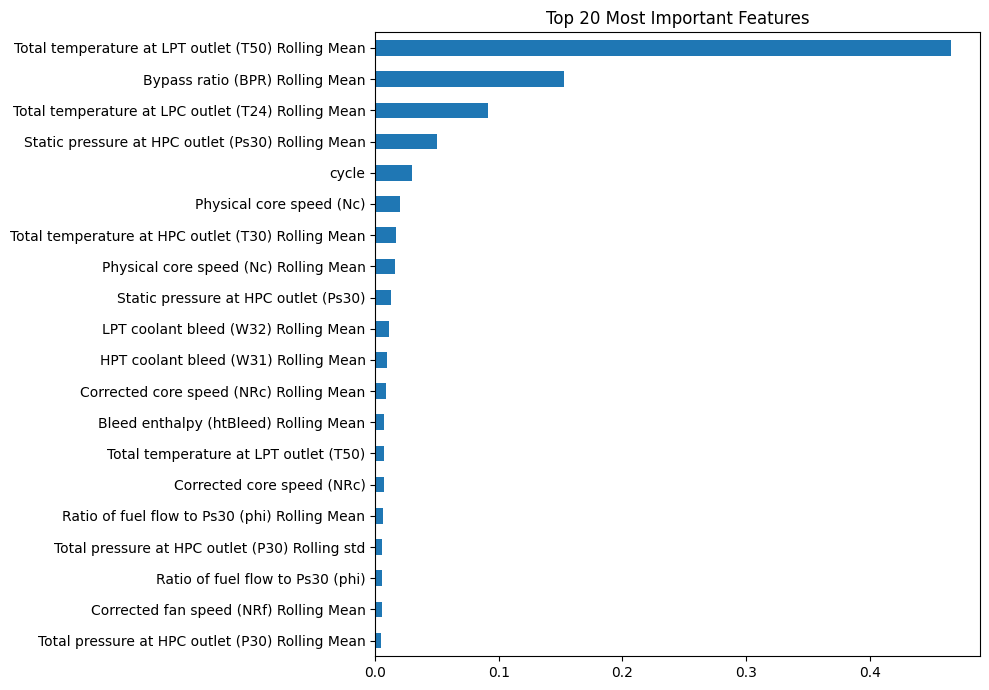

In [38]:
top_features = pd.Series(data=model.feature_importances_, index=feature_cols).nlargest(n=20)
top_features.sort_values(inplace=True)

top_features.rename(
    {col:updated_sensor_mapping.get(col, col) for col in train_data.columns},
    inplace=True)

plt.figure(figsize=(10,7))
top_features.plot(kind='barh')
plt.title("Top 20 Most Important Features")
plt.tight_layout()
plt.show()